In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn import preprocessing, model_selection
import csv
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import time
import json
import random

In [2]:
print(tf.__version__)
print(tf.config.list_physical_devices())

2.10.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data Preparation

In [3]:
def get_dataset(directory, lag, excluded_name=[]):
    data = pd.DataFrame(columns=['data', 'label'])
    for foldername in os.listdir(directory):        
        folder = os.path.join(directory, foldername)
        # print(folder)
        if str(lag) in folder:
            # print(os.listdir(folder))
            for name in os.listdir(folder):
                if name in excluded_name:
                    # print(name)
                    continue
                filename = os.path.join(folder, name)
                # print(filename)
                for files in os.listdir(filename):
                    rel_path = os.path.join(filename, files)
                    # print(rel_path)
                    temp_label = folder
                    if "autism" in temp_label:
                        label = 'autism'
                    else:
                        label = 'normal'

                    temp_data = pd.DataFrame(columns=['data', 'label'], index=[0])

                    rwb = np.load(rel_path)
                    rwb.astype(np.float64).reshape(-1,1)
                                    
                    temp_data.loc[0, "data"] = rwb
                    temp_data['label'] = label
                    data = pd.concat([data, temp_data], ignore_index=True)
    label_map = {"autism": 1, "normal": 0}
    data['label_map'] = data['label'].map(label_map)      
    return data

In [4]:
def remove_missing_value(data):
    series_list = np.vstack(data["data"].values)
    labels_list = data["label_map"].values    
    missing_indices = np.where(np.isnan(series_list).any(axis=1))[0]

    clean_data = data.drop(index=data.index[missing_indices])
    return clean_data

In [5]:
# temp_data = pd.DataFrame(columns=['data', 'label'], index=[0])
# rwb = np.load("datasets/features/rwb/segment_1 seconds/autism_256/bader/Bader_segment_100.csv_bispectrum.npy")
# rwb.astype(np.float64).reshape(-1,1)
# temp_data.loc[0, "data"] = rwb
# temp_data['label'] = "autism"


In [6]:
def save_dataset(data, des_path):
    if not os.path.exists(des_path):
        os.makedirs(des_path)
    data.save(des_path)

In [7]:
def get_train_test(data, train_split: float):
    train_x, test_x, train_y, test_y = model_selection.train_test_split(
        data['data'],
        data[['label', 'label_map']],
        train_size=train_split,
        stratify=data['label_map']
    )

    train_df = pd.DataFrame(columns=['data', 'label', 'label_map'])
    test_df = pd.DataFrame(columns=['data', 'label', 'label_map'])

    train_df["data"] = train_x
    train_df[['label', 'label_map']] = train_y

    test_df["data"] = test_x
    test_df[['label', 'label_map']] = test_y

    return train_df, test_df

In [8]:
def get_batch(data):
    # loading extracted feature & label
    # x = get_dataset(path, lag, excluded_name)

    # scaler = preprocessing.MinMaxScaler()

    series_list = np.vstack(data["data"].values)

    # series_list = series_list.reshape(-1, 366, 1)

    labels_list = data["label_map"].values
        
    # y = keras.utils.to_categorical(y[0])
    dataset = tf.data.Dataset.from_tensor_slices((series_list,labels_list))
    dataset = dataset.shuffle(len(labels_list))

    # train_size = int(train_split * len(labels_list))  
    # test_size = len(labels_list) - train_size  

    # train_dataset = dataset.take(train_size)
    # test_dataset = dataset.skip(train_size)

    BATCH_SIZE = 32

    dataset = dataset.batch(BATCH_SIZE)

    return dataset

In [9]:
def relative_transform(data):    
    series_list = np.vstack(data["data"].values)
    labels_list = data["label_map"].values  

    relative_energy = np.zeros([series_list.shape[0], series_list.shape[1]])
    for i, series in enumerate(series_list):
        total_energy = np.sum(series)
        relative_energy[i] = [(s / total_energy) * 100 for s in series]
    relative_energy_list = [arr for arr in relative_energy]
    data["data"] = relative_energy_list
    return data    

In [10]:
# train_x, test_x, train_y, test_y = model_selection.train_test_split(
#         data['data'],
#         data[['label', 'label_map']],
#         train_size=0.8,
#         stratify=data['label_map']
#     )

# train_df = pd.DataFrame(columns=['data', 'label', 'label_map'])
# test_df = pd.DataFrame(columns=['data', 'label', 'label_map'])

# train_df["data"] = train_x
# train_df[['label', 'label_map']] = train_y

# test_df["data"] = test_x
# test_df[['label', 'label_map']] = test_y

In [11]:
# excluded = ["zyad"]
# data = get_dataset(data_dir, 256, excluded_name=excluded)

In [12]:
# temp = data["data"].values
# series_list = np.vstack(temp)
# series_list = series_list.reshape(-1, 96, 1)

In [18]:
SEGMENT_TIME = 1

data_dir = f"datasets/features/bispectrum_pyramid/segment_{SEGMENT_TIME} seconds"

train_dir = f"datasets/tf_batch/bispectrum_pyramid/segment_{SEGMENT_TIME} seconds/train"
test_dir = f"datasets/tf_batch/bispectrum_pyramid/segment_{SEGMENT_TIME} seconds/test"

In [14]:
# excluded = ["zyad"]
# data = get_dataset(data_dir, 256, excluded)

In [15]:
# data.shape[0]

In [16]:
# series_list = np.vstack(data["data"].values)
# labels_list = data["label_map"].values    
# missing_indices = np.where(np.isnan(series_list).any(axis=1))[0]

# clean_data = data.drop(index=data.index[missing_indices])

In [17]:
# clean_data.shape[0]

In [19]:
excluded = ["zyad"]
train_split = 0.8
LAG = [256, 128, 64]

for lag in LAG:
    data = get_dataset(data_dir, lag, excluded)
    print(data.shape)
    data = relative_transform(data)
    data = remove_missing_value(data)
    print(data.shape)
    train_data, test_data = get_train_test(data, train_split)
    print("train: ", train_data.shape)
    print("test: ", test_data.shape)
    train_batch = get_batch(train_data)
    test_batch = get_batch(test_data)
    tf.data.Dataset.save(train_batch, f"{train_dir}_{lag}")
    tf.data.Dataset.save(test_batch, f"{test_dir}_{lag}")

(15434, 3)


C:\Users\farra\AppData\Local\Temp\ipykernel_2592\3426103326.py:8: RuntimeWarning: invalid value encountered in scalar divide
  relative_energy[i] = [(s / total_energy) * 100 for s in series]


(15399, 3)
train:  (12319, 3)
test:  (3080, 3)
(15434, 3)


C:\Users\farra\AppData\Local\Temp\ipykernel_2592\3426103326.py:8: RuntimeWarning: invalid value encountered in scalar divide
  relative_energy[i] = [(s / total_energy) * 100 for s in series]


(15399, 3)
train:  (12319, 3)
test:  (3080, 3)
(15434, 3)


C:\Users\farra\AppData\Local\Temp\ipykernel_2592\3426103326.py:8: RuntimeWarning: invalid value encountered in scalar divide
  relative_energy[i] = [(s / total_energy) * 100 for s in series]


(15399, 3)
train:  (12319, 3)
test:  (3080, 3)


### Exploratory Data Analysis

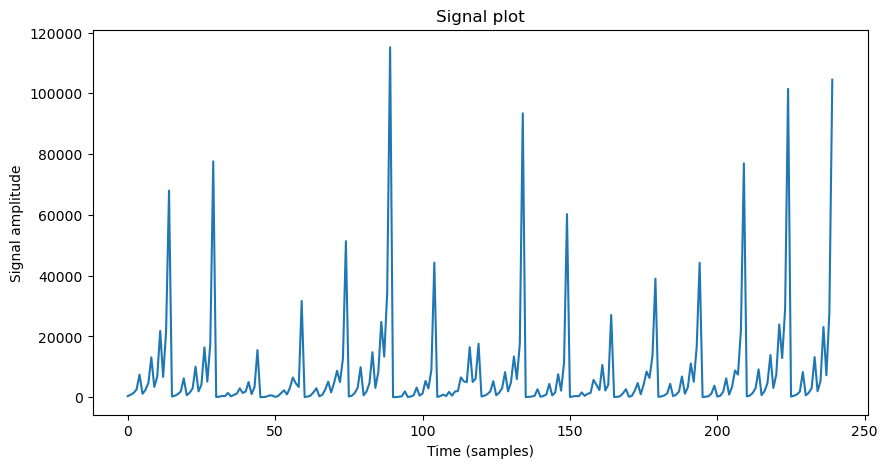

In [20]:
# Load the CSV file into a DataFrame
LAG = [64]

signal = np.load(f"datasets/features/bispectrum_pyramid/segment_{SEGMENT_TIME} seconds/normal_{LAG[0]}/amer/Amer_segment_1.csv_bispectrum.npy")
# Extract the signal values from the DataFrame

# Create a time axis for the signal
t = range(len(signal))

fig, ax = plt.subplots(figsize=(10, 5))
# Plot the signal
ax.plot(t, signal)
ax.set_xlabel('Time (samples)')
ax.set_ylabel('Signal amplitude')
ax.set_title('Signal plot')
plt.show()

(240,)


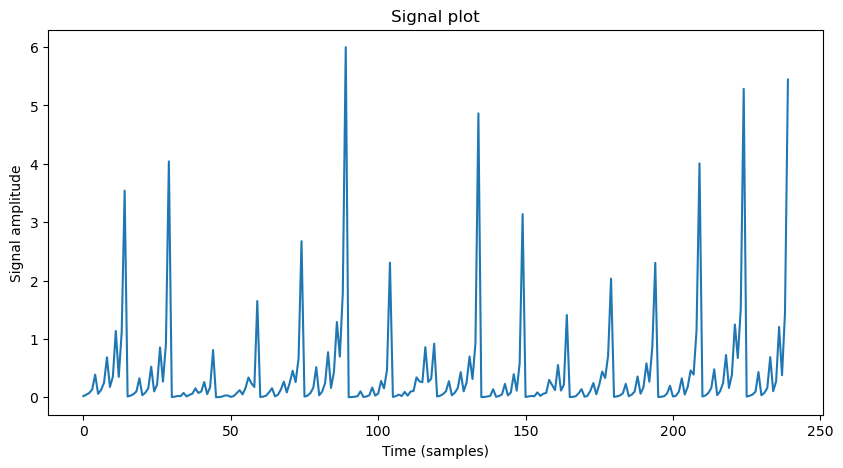

In [20]:
rel_signal = np.array([(s / np.sum(signal)) * 100 for s in signal])

print(rel_signal.shape)
t = range(len(signal))

fig, ax = plt.subplots(figsize=(10, 5))
# Plot the signal
ax.plot(t, rel_signal)
ax.set_xlabel('Time (samples)')
ax.set_ylabel('Signal amplitude')
ax.set_title('Signal plot')
plt.show()

### Model Definition

In [21]:
input_size = 240

def create_model():
    model = keras.models.Sequential()

    model.add(layers.Input(shape=(input_size,)))
    model.add(layers.Reshape((input_size, 1)))

    model.add(layers.Flatten())

    model.add(layers.Dense(512, activation="relu"))

    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(256, activation="relu"))

    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(1, activation="sigmoid"))

    return model
    

In [22]:
sample_model = create_model()
sample_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 240, 1)            0         
                                                                 
 flatten (Flatten)           (None, 240)               0         
                                                                 
 dense (Dense)               (None, 512)               123392    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 2

### Define Callbacks

In [23]:
def myCallbacks(log_dir):
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
    early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='acc',
    patience=50,
    mode='max')
    model_path = os.path.join(log_dir,'best_model.h5')
    mc = tf.keras.callbacks.ModelCheckpoint(model_path, monitor='val_acc', mode='max', verbose=1, save_best_only=True)
    return [tensorboard_callback, early_stopping, mc]
    

### Main Program

In [24]:
lags = [256,128,64]
# folds = ['train_1', 'test_1', 'epoch_1', 'train_2', 'test_2', 'epoch_2']
time_measured = ['Wall_Time_1', 'CPU_Time_1', 'Wall_Time_2', 'CPU_Time_2']
epochs = 1000
log_dirs = [f"train_logs/logs1/BISPECTRUM_PYRAMID_FILTER_512_256_Adam"]

In [25]:
for log_dir in log_dirs:
    recap = pd.DataFrame(index=lags, columns=range(1, 6))
    training_time = pd.DataFrame(index=lags, columns=[f'CPU_Time_{i}' for i in range(1, 6)] + [f'Wall_Time_{i}' for i in range(1, 6)])

    for lag in lags:
        train_temp_dir = train_dir + '_' + str(lag)
        train = tf.data.Dataset.load(train_temp_dir)
        flattened_train = train.unbatch()

        train_data = list(flattened_train.as_numpy_iterator())
        train_size = len(list(train_data))

        kf = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)

        for fold, (train_index, val_index) in enumerate(kf.split(train_data), 1):
            train_fold_data = ([train_data[i][0] for i in train_index], [train_data[i][1] for i in train_index])
            val_fold_data = ([train_data[i][0] for i in val_index], [train_data[i][1] for i in val_index])

            train_fold = tf.data.Dataset.from_tensor_slices(train_fold_data).batch(32)
            val_fold = tf.data.Dataset.from_tensor_slices(val_fold_data).batch(32)

            log_path = os.path.join(log_dir, str(fold), str(lag))

            model = create_model()        
            model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['acc'])

            cpu_start = time.process_time()
            wt_start = time.time()

            history = model.fit(train_fold, epochs=epochs, validation_data=val_fold, callbacks=myCallbacks(log_path), verbose=2)

            wt_end = time.time()
            cpu_end = time.process_time()
            wall_time = wt_end - wt_start
            cpu_time = cpu_end - cpu_start

            training_time.loc[lag, f'CPU_Time_{fold}'] = cpu_time
            training_time.loc[lag, f'Wall_Time_{fold}'] = wall_time

            recap.loc[lag, fold] = history.history['acc'][-1]


    # Evaluate on the test dataset after cross-validation
    test_temp_dir = test_dir + '_' + str(lag)
    test_ds = tf.data.Dataset.load(test_temp_dir)
    results = model.evaluate(test_ds, callbacks=myCallbacks(log_path))

    recap[f'test_{lag}'] = results[1]

    log_recap_dir = os.path.join(log_dir, 'Recap')
    if not os.path.exists(log_recap_dir):
        os.makedirs(log_recap_dir)

    recap.to_csv(os.path.join(log_recap_dir, 'recap.csv'))
    training_time.to_csv(os.path.join(log_recap_dir, 'Training_time.csv'))

Epoch 1/1000

Epoch 1: val_acc improved from -inf to 0.80844, saving model to train_logs/logs1/BISPECTRUM_PYRAMID_FILTER_512_256_Adam\1\256\best_model.h5
308/308 - 3s - loss: 0.5665 - acc: 0.7400 - val_loss: 0.4415 - val_acc: 0.8084 - 3s/epoch - 11ms/step
Epoch 2/1000

Epoch 2: val_acc improved from 0.80844 to 0.83117, saving model to train_logs/logs1/BISPECTRUM_PYRAMID_FILTER_512_256_Adam\1\256\best_model.h5
308/308 - 1s - loss: 0.4385 - acc: 0.8030 - val_loss: 0.3856 - val_acc: 0.8312 - 1s/epoch - 4ms/step
Epoch 3/1000

Epoch 3: val_acc improved from 0.83117 to 0.85106, saving model to train_logs/logs1/BISPECTRUM_PYRAMID_FILTER_512_256_Adam\1\256\best_model.h5
308/308 - 1s - loss: 0.3857 - acc: 0.8319 - val_loss: 0.3441 - val_acc: 0.8511 - 1s/epoch - 4ms/step
Epoch 4/1000

Epoch 4: val_acc improved from 0.85106 to 0.87013, saving model to train_logs/logs1/BISPECTRUM_PYRAMID_FILTER_512_256_Adam\1\256\best_model.h5
308/308 - 1s - loss: 0.3507 - acc: 0.8472 - val_loss: 0.3146 - val_acc:

KeyboardInterrupt: 

In [26]:
# Load Best Model
LAG = 64

test_dir = f"datasets/tf_batch/bispectrum_pyramid_relative/segment_{SEGMENT_TIME} seconds/test_{LAG}"
test_ds = tf.data.Dataset.load(test_dir)
model_dir = [f"train_logs/logs1/BISPECTRUM_PYRAMID_FILTER_RELATIVE_512_256_Adam/{i}/{LAG}/best_model.h5" for i in range(1,6)]

In [27]:
flattened_test = test_ds.unbatch()
test_data = list(flattened_test.as_numpy_iterator())

In [28]:
test_data_value = np.array([test_data[i][0] for i in range(len(test_data))])
test_data_label = np.array([test_data[i][1] for i in range(len(test_data))])

In [29]:
test_data_value.reshape(test_data_value.shape[0], -1).shape

(3080, 240)

In [30]:
results = []

for i, model_path in enumerate(model_dir):
    model = keras.models.load_model(model_path)
    loss, acc = model.evaluate(test_ds)
    print(loss, acc)
    pred = model.predict(test_data_value.reshape(test_data_value.shape[0], -1))
    results.append(pred)

97/97 [==============================] - 1s 4ms/step - loss: 0.3324 - acc: 0.8896
0.3323672413825989 0.8896104097366333
97/97 [==============================] - 0s 3ms/step - loss: 0.4966 - acc: 0.8886
0.49660032987594604 0.8886363506317139
97/97 [==============================] - 1s 4ms/step - loss: 0.4443 - acc: 0.9000
0.44430723786354065 0.8999999761581421
97/97 [==============================] - 0s 4ms/step - loss: 0.6288 - acc: 0.8873
0.6287662982940674 0.8873376846313477
97/97 [==============================] - 1s 4ms/step - loss: 0.3741 - acc: 0.8916
0.37407365441322327 0.8915584683418274
97/97 [==============================] - 0s 2ms/step


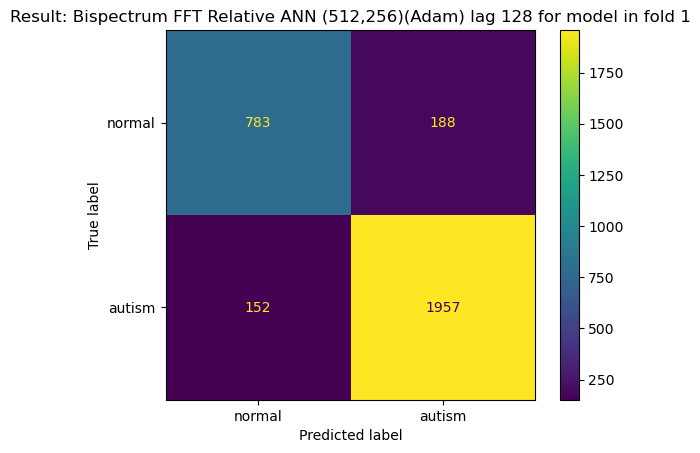

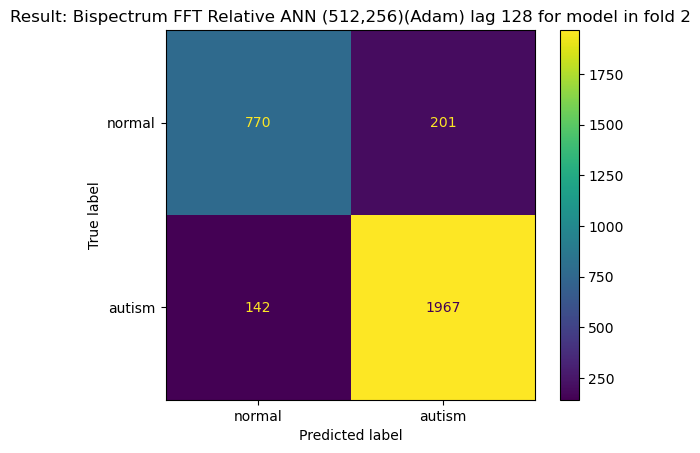

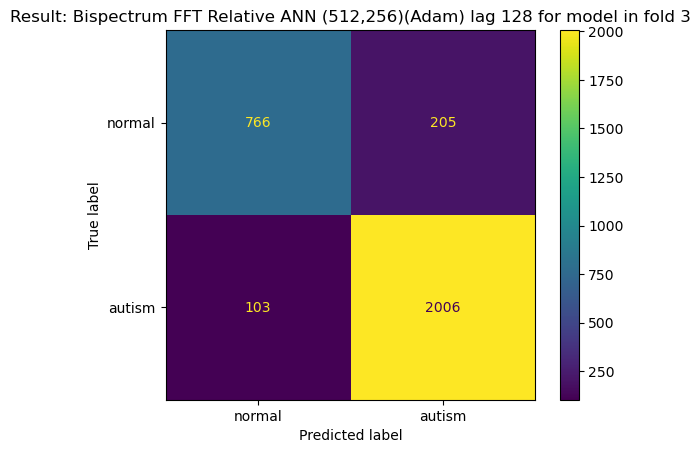

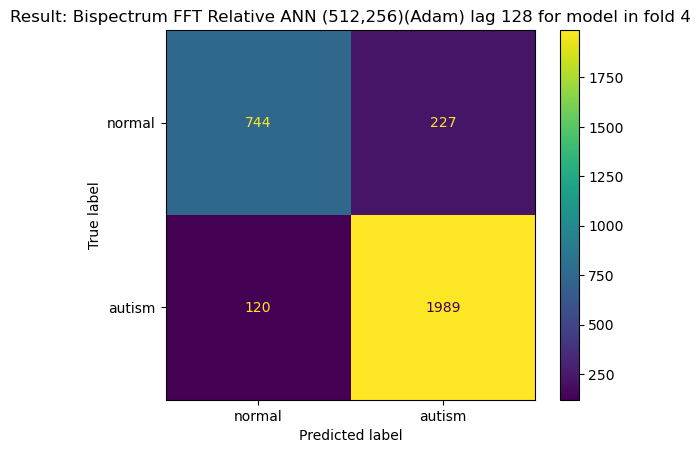

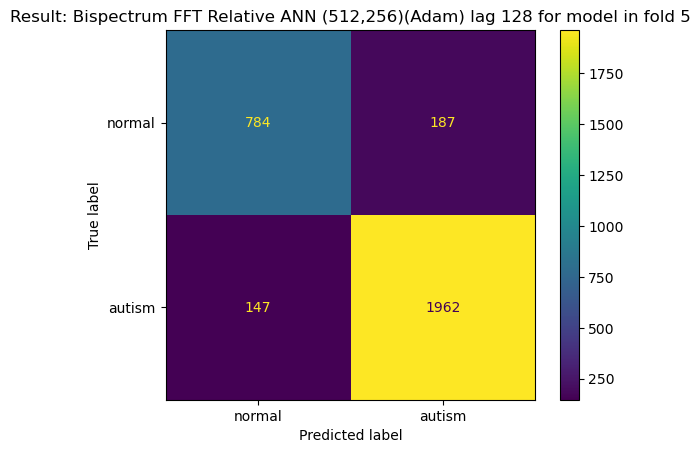

In [31]:
from sklearn import metrics

for i, res in enumerate(results, 1):
    pred = np.round(res.reshape(res.shape[0])).astype(bool)
    confusion_matrix = metrics.confusion_matrix(test_data_label.astype(bool), pred)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['normal', 'autism'])
    cm_display.plot()
    plt.title(f"Result: Bispectrum FFT Relative ANN (512,256)(Adam) lag 128 for model in fold {i}")
    plt.show()

In [32]:
for i, res in enumerate(results, 1):
    pred = np.round(res.reshape(res.shape[0])).astype(bool)
    test_data_label = test_data_label.astype(bool)  

    print(f"Result: BISPECTRUM FILTER PYRAMID ANN (512,256)(Adam) lag 128 for model in fold {i}")

    TP = np.sum((test_data_label == True) & (pred == True))
    FP = np.sum((test_data_label == False) & (pred == True))
    TN = np.sum((test_data_label == False) & (pred == False))
    FN = np.sum((test_data_label == True) & (pred == False))  

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"Accuracy: {accuracy}")
    print(f"F1-score: {f1_score}")
    print("\n")

Result: BISPECTRUM FILTER PYRAMID ANN (512,256)(Adam) lag 128 for model in fold 1
Precision: 0.9123543123543123
Recall: 0.9279279279279279
Accuracy: 0.8896103896103896
F1-score: 0.920075223319229


Result: BISPECTRUM FILTER PYRAMID ANN (512,256)(Adam) lag 128 for model in fold 2
Precision: 0.9072878228782287
Recall: 0.93266951161688
Accuracy: 0.8886363636363637
F1-score: 0.9198036006546645


Result: BISPECTRUM FILTER PYRAMID ANN (512,256)(Adam) lag 128 for model in fold 3
Precision: 0.9072817729534147
Recall: 0.9511616880037933
Accuracy: 0.9
F1-score: 0.9287037037037037


Result: BISPECTRUM FILTER PYRAMID ANN (512,256)(Adam) lag 128 for model in fold 4
Precision: 0.8975631768953068
Recall: 0.9431009957325747
Accuracy: 0.8873376623376623
F1-score: 0.9197687861271676


Result: BISPECTRUM FILTER PYRAMID ANN (512,256)(Adam) lag 128 for model in fold 5
Precision: 0.9129827826896231
Recall: 0.930298719772404
Accuracy: 0.8915584415584416
F1-score: 0.9215594175669328




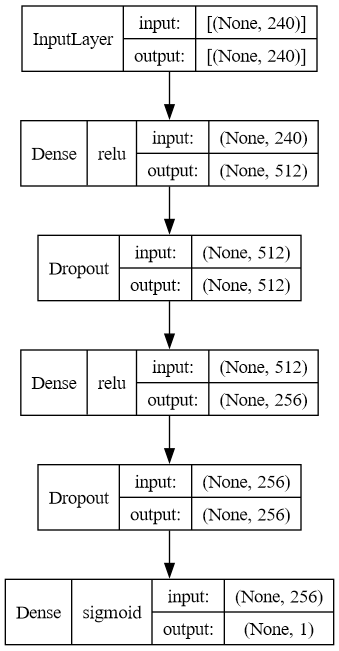

In [36]:
test_model = keras.models.Sequential()

test_model.add(layers.Input(shape=(240,)))

test_model.add(layers.Dense(512, activation="relu"))

test_model.add(layers.Dropout(0.5))

test_model.add(layers.Dense(256, activation="relu"))

test_model.add(layers.Dropout(0.5))

test_model.add(layers.Dense(1, activation="sigmoid"))

keras.utils.plot_model(test_model, show_layer_activations=True, show_shapes=True, show_layer_names=False)

In [29]:
# for log_dir in log_dirs:
#     recap = pd.DataFrame(index=lags, columns=folds)
#     training_time = pd.DataFrame(index=lags, columns=time_measured)
#     for fold in range(1,3):
#         for lag in lags:
#             if fold == 2:
#                 train_dir, test_dir = test_dir, train_dir
            
#             train_temp_dir = train_dir + '_' + str(lag)
#             test_temp_dir = test_dir + '_' + str(lag)

#             train = get_batch(train_temp_dir)
#             test_ds = get_batch(test_temp_dir)

#             train_size = int(len(list(train.as_numpy_iterator()))*0.8)
#             train_ds = train.take(train_size)
#             val_ds = train.skip(train_size)

#             log_path = os.path.join(log_dir, str(fold), str(lag))

#             model = create_model()
#             model.summary()

#             model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['acc'])

#             cpu_start = time.process_time()
#             wt_start = time.time()

#             history = model.fit(train_ds, epochs=epochs, validation_data=(val_ds), callbacks = myCallbacks(log_path))

#             wt_end = time.time()
#             cpu_end = time.process_time()
#             wall_time = wt_end - wt_start
#             cpu_time = cpu_end - cpu_start
#             training_time.loc[lag, 'CPU_Time'+ '_' + str(fold)] = cpu_time
#             training_time.loc[lag, 'Wall_Time'+ '_' + str(fold)] = wall_time

#             results = model.evaluate(test_ds, callbacks = myCallbacks(log_path))

#             recap.loc[lag, 'train'+ '_' + str(fold)] = history.history['acc']
#             recap.loc[lag, 'test'+ '_' + str(fold)] = results[1]
#             recap.loc[lag, 'epoch'+ '_' + str(fold)] = len(history.history['acc'])
#     log_dir = os.path.join(log_dir,'Recap')
#     if not os.path.exists(log_dir):
#         os.makedirs(log_dir)
#     recap.to_csv(os.path.join(log_dir,'recap.csv'))
#     training_time.to_csv(os.path.join(log_dir,'Training_time.csv'))

In [30]:
%load_ext tensorboard

In [31]:
! tensorboard --logdir c:/Users/farra/Documents/Pribadi/EEG/EEG-Autism-Classification --port=8000

^C


In [ ]:
%tensorboard --logdir logs --port=8000

In [ ]:
! cd

c:\Users\farra\Documents\Pribadi\EEG\EEG-Autism-Classification
